# Breast Ultrasound Image Classification 

This notebook builds a CNN model to classify breast ultrasound images into three categories:
- **Malignant** (cancerous tumors)
- **Benign** (non-cancerous tumors)
- **Normal** (healthy tissue)

## Approach
We use **transfer learning with ResNet18** pretrained on ImageNet, modified to accept 2-channel input (grayscale image + tumor mask).

## Prerequisites
Run `msb_data_preprocessing.ipynb` first to prepare the dataset splits.

In [1]:
# Standard libraries
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
# Select GPU if available (MPS for Mac, CUDA for NVIDIA, else CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
# Data paths (generated by msb_data_preprocessing.ipynb)
DATA_DIR = Path("../data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VAL_CSV = DATA_DIR / "val_split.csv"
TEST_CSV = DATA_DIR / "test_split.csv"

# Class definitions
CLASSES = ["malignant", "benign", "normal"]
label_map = {c: i for i, c in enumerate(CLASSES)}  # {"malignant": 0, "benign": 1, "normal": 2}

## 1. Data Loading

Load the preprocessed dataset and create data loaders. The preprocessing notebook handles:
- Train/Validation/Test split (70/15/15)
- Image resizing to 224×224
- Mask merging for tumor regions
- Data augmentation for training

Using device: mps
Total: 780 | Train: 563 | Val: 100 | Test: 117

Class distribution:
Train: [152 315  96]
Val: [27 56 17]
Test: [31 66 20]


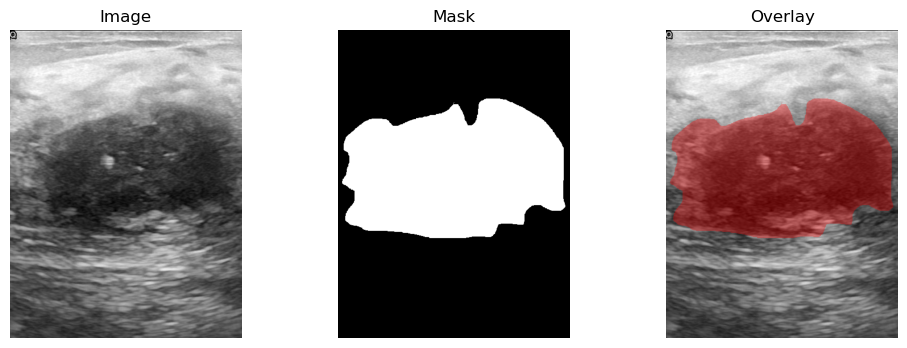

Saved train_split.csv, val_split.csv, and test_split.csv to ../data/


In [4]:
# Import helper functions from preprocessing notebook:
%run msb_data_preprocessing.ipynb

In [5]:
# Configuration
BATCH_SIZE = 32
USE_MASKS = True  # Use 2-channel input: grayscale image + tumor mask

# Get transforms (with augmentation for training, none for eval)
transform, train_transform = get_default_transforms()

# Create datasets and data loaders
datasets, loaders = prepare_data_pipeline(
    TRAIN_CSV, VAL_CSV, TEST_CSV, label_map,
    batch_size=BATCH_SIZE,
    use_masks=USE_MASKS,
    transform=transform,
    train_transform=train_transform,
)

# Unpack for convenience
train_dataset, val_dataset, test_dataset = datasets['train'], datasets['val'], datasets['test']
train_loader, val_loader, test_loader = loaders['train'], loaders['val'], loaders['test']

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 563 | Val: 100 | Test: 117


## 2. Model Architecture

We use **ResNet18** with transfer learning:
- Leverage on pretrained ImageNet (1M+ images, 1000 classes)
- Modified first conv layer to accept 2 channels (grayscale + mask)
- Replace final FC layer with 3-class classifier

In [6]:
class BreastUS_ResNet(nn.Module):
    """
    Transfer learning with ResNet18 for breast ultrasound classification.
    - Pretrained ResNet18 backbone (ImageNet weights)
    - Modified first conv to accept 2 channels (grayscale + mask)
    - Custom classifier head with dropout
    """
    def __init__(self, num_classes=3, input_channels=2, pretrained=True):
        super(BreastUS_ResNet, self).__init__()
        
        # Load pretrained ResNet18
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        
        # first conv layer: 2 channels
        # Average the pretrained weights across RGB channels
        old_conv = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(
            input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        
        # Initialize with averaged pretrained weights
        if pretrained:
            with torch.no_grad():
                # Average RGB weights -> single channel, then tile for input_channels
                avg_weights = old_conv.weight.mean(dim=1, keepdim=True)
                self.backbone.conv1.weight = nn.Parameter(
                    avg_weights.repeat(1, input_channels, 1, 1)
                )
        
        # Replace classifier head
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

In [7]:
# Calculate class weights to handle imbalanced data
# Formula: weight = total_samples / (num_classes * class_count)
train_df = pd.read_csv(TRAIN_CSV)
class_counts = train_df['label'].value_counts()
print("Class distribution:")
for label, count in class_counts.items():
    print(f"  {label}: {count} ({count/len(train_df)*100:.1f}%)")

# Compute inverse-frequency weights
class_to_idx = {name: idx for idx, name in enumerate(CLASSES)}
class_weights = np.ones(len(CLASSES))
for class_name, count in class_counts.items():
    idx = class_to_idx[class_name]
    class_weights[idx] = len(train_df) / (len(CLASSES) * count)

print(f"\nClass weights: malignant={class_weights[0]:.2f}, benign={class_weights[1]:.2f}, normal={class_weights[2]:.2f}")

# Loss function with class weights
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

Class distribution:
  benign: 315 (56.0%)
  malignant: 152 (27.0%)
  normal: 96 (17.1%)

Class weights: malignant=1.23, benign=0.60, normal=1.95


As the data has more benign images compared to malignant and normal images, I added class weights to balance out. 

In [8]:
def compute_correct_labels(outputs, labels):
    """Count correct predictions from model outputs."""
    _, preds = torch.max(outputs, 1)
    correct = torch.sum(preds == labels).item()
    total = labels.size(0)
    return correct, total

In [25]:
def training_loop(model, optimizer, scheduler, num_epochs, train_loader, val_loader, test_loader, class_names):
    """
    Train the model and track losses.
    
    Args:
        model: PyTorch model to train
        optimizer: Optimizer (e.g., Adam)
        scheduler: Learning rate scheduler (or None)
        num_epochs: Number of training epochs
        train_loader, val_loader, test_loader: Data loaders
        class_names: List of class names for logging
    
    Returns:
        train_losses, val_losses, test_losses: Loss history
    """
    train_losses, val_losses, test_losses = [], [], []
    best_val_acc = 0.0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_class_correct = {i: 0 for i in range(len(class_names))}
        val_class_total = {i: 0 for i in range(len(class_names))}
        
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                
                for i in range(len(y)):
                    label = y[i].item()
                    pred = preds[i].item()
                    val_class_total[label] += 1
                    if label == pred:
                        val_class_correct[label] += 1

        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total

        model.eval()
        test_loss = 0
        
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)
        
        if scheduler is not None:
            scheduler.step(avg_val_loss)
        
        val_class_accs = []
        for i in range(len(class_names)):
            if val_class_total.get(i, 0) > 0:
                val_class_accs.append(val_class_correct[i] / val_class_total[i])
        
        if len(val_class_accs) == len(class_names):
            min_class_acc = min(val_class_accs)
            balanced_score = val_acc * (0.7 + 0.3 * min_class_acc)
        else:
            balanced_score = val_acc
        
        if balanced_score > best_val_acc:
            best_val_acc = balanced_score
            best_model_state = model.state_dict().copy()

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        test_losses.append(avg_test_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Accuracy: {val_acc*100:.1f}%")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses, test_losses

In [10]:
# Model Initialization
input_channels = 2 if USE_MASKS else 1
model = BreastUS_ResNet(
    num_classes=3,
    input_channels=input_channels,
    pretrained=True
).to(device)

In [11]:
# Print model size
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 11,174,915
Trainable parameters: 11,174,915


This means that RestNet18 has ~11M numbers defining the model and all the parameters are being updated during training. 

Since both numbers are the same, **no layer is frozen**, which means the model learn entirely from scratch with some help from pretrained weights (features, edges, shapes of the tumors). 

In [12]:
# Training Configuration
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
EPOCHS = 50

In [ ]:
# Train the model
train_losses, val_losses, test_losses = training_loop(
    model, optimizer, scheduler, EPOCHS, 
    train_loader, val_loader, test_loader, CLASSES
)

Epoch [1/50] Train Loss: 0.9202 | Test Loss: 0.8193 | Accuracy: 59.0%
Epoch [2/50] Train Loss: 0.6624 | Test Loss: 0.6585 | Accuracy: 62.0%
Epoch [3/50] Train Loss: 0.4916 | Test Loss: 0.5414 | Accuracy: 76.0%
Epoch [4/50] Train Loss: 0.3793 | Test Loss: 0.5498 | Accuracy: 80.0%
Epoch [5/50] Train Loss: 0.3389 | Test Loss: 0.5035 | Accuracy: 81.0%
Epoch [6/50] Train Loss: 0.2796 | Test Loss: 0.4705 | Accuracy: 81.0%
Epoch [7/50] Train Loss: 0.2485 | Test Loss: 0.4176 | Accuracy: 83.0%
Epoch [8/50] Train Loss: 0.2381 | Test Loss: 0.4147 | Accuracy: 80.0%
Epoch [9/50] Train Loss: 0.1796 | Test Loss: 0.4275 | Accuracy: 82.0%
Epoch [10/50] Train Loss: 0.1463 | Test Loss: 0.5237 | Accuracy: 85.0%
Epoch [11/50] Train Loss: 0.1488 | Test Loss: 0.4484 | Accuracy: 84.0%
Epoch [12/50] Train Loss: 0.1137 | Test Loss: 0.4322 | Accuracy: 86.0%
Epoch [13/50] Train Loss: 0.0892 | Test Loss: 0.4854 | Accuracy: 85.0%
Epoch [14/50] Train Loss: 0.0764 | Test Loss: 0.4668 | Accuracy: 86.0%
Epoch [15/50] T

## 3. Model Evaluation

Evaluate the trained model on the test set and visualize results.

In [19]:
def evaluate_model(model, test_loader, device, class_names):
    """Evaluate model on test set and return accuracy and predictions."""
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    # Per-class statistics
    class_correct = {i: 0 for i in range(len(class_names))}
    class_total = {i: 0 for i in range(len(class_names))}
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
            correct += (preds == y).sum().item()
            total += y.size(0)
            
            # Count per-class accuracy
            for i in range(len(y)):
                label = y[i].item()
                pred = preds[i].item()
                class_total[label] += 1
                if label == pred:
                    class_correct[label] += 1
    
    accuracy = correct / total
    print(f"\nOverall Test Accuracy: {accuracy * 100:.2f}%")
    print("\nPer-class Test Accuracy:")
    for i, class_name in enumerate(class_names):
        if class_total[i] > 0:
            class_acc = class_correct[i] / class_total[i] * 100
            print(f"  {class_name}: {class_correct[i]}/{class_total[i]} ({class_acc:.2f}%)")
    
    return np.array(all_preds), np.array(all_labels)

# Evaluate the trained model
test_preds, test_labels = evaluate_model(model, test_loader, device, CLASSES)


Overall Test Accuracy: 89.74%

Per-class Test Accuracy:
  malignant: 26/31 (83.87%)
  benign: 60/66 (90.91%)
  normal: 19/20 (95.00%)


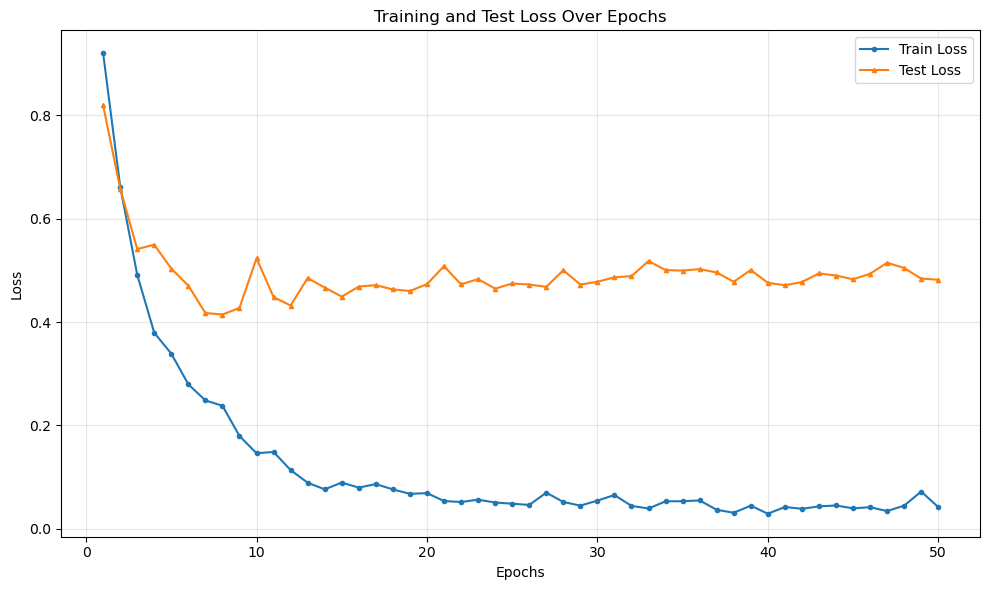

In [22]:
# Plot training and test loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, 'o-', label='Train Loss', markersize=3)
plt.plot(range(1, EPOCHS + 1), test_losses, '^-', label='Test Loss', markersize=3)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Test Loss Over Epochs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sample Predictions Visualization

Display sample images from each class with their predictions. Green = correct, Red = incorrect.

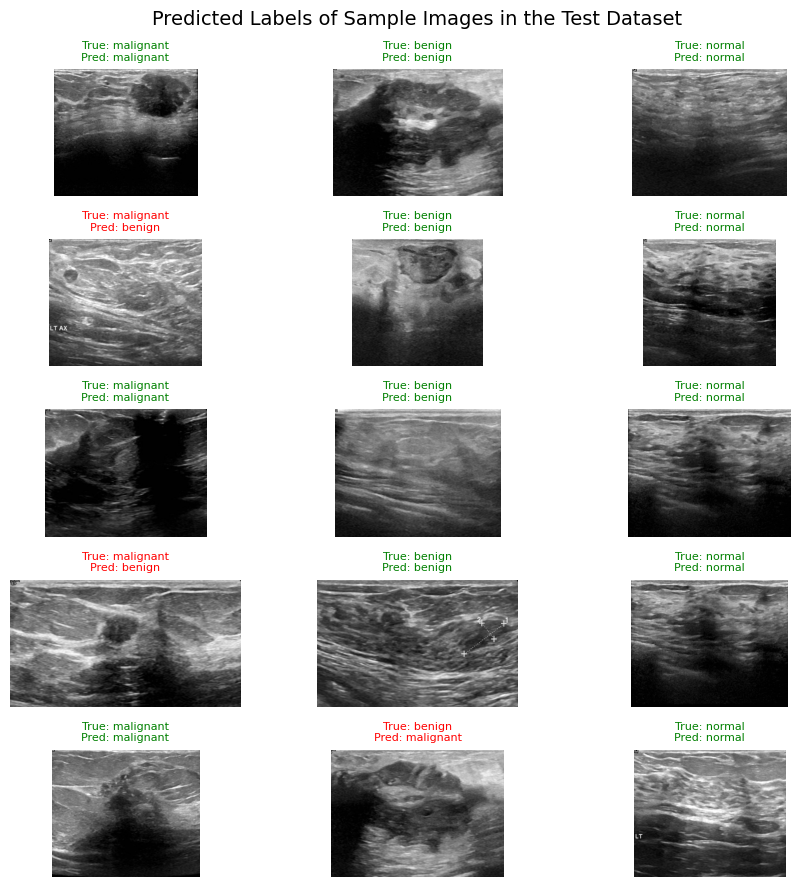

In [20]:
# Visualize predictions on sample test images
model.eval()
test_df = pd.read_csv(TEST_CSV)

num_samples_per_class = 5
fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(num_samples_per_class, len(CLASSES))

reverse_label_map = {v: k for k, v in label_map.items()}

for class_idx, class_name in enumerate(CLASSES):
    class_images = test_df[test_df['label'] == class_name].head(num_samples_per_class)
    
    for row_idx, (_, row) in enumerate(class_images.iterrows()):
        img_path = row['path']
        image = Image.open(img_path).convert('RGB')
        
        if USE_MASKS:
            mask = merge_masks_pil(img_path)
            mask_pil = Image.fromarray(mask)
            img_gray = image.convert('L')
            
            img_gray = img_gray.resize((224, 224), Image.LANCZOS)
            mask_pil = mask_pil.resize((224, 224), Image.NEAREST)
            
            img_gray_t = transforms.ToTensor()(img_gray)
            mask_t = transforms.ToTensor()(mask_pil)
            
            img_gray_t = transforms.Normalize(mean=[0.5], std=[0.5])(img_gray_t)
            mask_t = transforms.Normalize(mean=[0.5], std=[0.5])(mask_t)
            
            input_tensor = torch.cat([img_gray_t, mask_t], dim=0).unsqueeze(0).to(device)
        else:
            img_gray = image.convert('L')
            input_tensor = transform(img_gray).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)
        predicted_class = reverse_label_map[predicted.item()]
        true_label = row['label']
        
        ax = fig.add_subplot(gs[row_idx, class_idx])
        ax.imshow(image)
        ax.axis('off')
        
        color = 'green' if predicted_class == true_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {predicted_class}', 
                     color=color, fontsize=8)

plt.suptitle('Predicted Labels of Sample Images in the Test Dataset', fontsize=14)
plt.tight_layout()
plt.show()

## Final Observation: CNN Model Performance

---

### Attempt 1: Simple CNN with Mask Input

**Model:** 4-block CNN (single conv per block), 2-channel input (grayscale + mask)

**Training:** CrossEntropyLoss with 3.0× weight on normal class, Adam lr=1e-4, 30 epochs

**Result:**
| Class | Accuracy |
|-------|----------|
| Malignant | 64.29% |
| Benign | 93.10% |
| Normal | 40.74% |
| **Overall** | **76.28%** |

**Issue:** Normal class accuracy too low (40.74%)

---

### Attempt 2: Complex CNN with Focal Loss

**Model:** 4-block CNN (double conv per block), AdaptiveAvgPool, BatchNorm

**Training:** Focal Loss (γ=1.5) with 1.6×/1.3× class weights, Adam lr=5e-4, 50 epochs

**Result:**
| Class | Accuracy |
|-------|----------|
| Malignant | 95.24% |
| Benign | 57.47% |
| Normal | 100.00% |
| **Overall** | **75.00%** |

**Issue:** Benign class accuracy too low (57.47%), training unstable

---

### Attempt 3: ResNet18 Transfer Learning (Current)

**Model:** ResNet18 pretrained on ImageNet, modified for 2-channel input

**Training:** CrossEntropyLoss with inverse-frequency weights, Adam lr=1e-4, 50 epochs

**Result:**
| Class | Accuracy |
|-------|----------|
| Malignant | 83.87% |
| Benign | 90.91% |
| Normal | 95.00% |
| **Overall** | **89.74%** |

**Why it works:**
- Pretrained features from ImageNet help detect edges, textures, and shapes
- Better generalization on small dataset (780 images)
- Balanced performance across all classes

---

### Summary

| Attempt | Overall | Malignant | Benign | Normal |
|---------|---------|-----------|--------|--------|
| 1. Simple CNN | 76% | 64% | 93% | 41% |
| 2. Complex CNN | 75% | 95% | 57% | 100% |
| **3. ResNet18** | **90%** | **84%** | **91%** | **95%** |

I have tried other methods, but these three give the overall better results, so I documented them here for reference.
